## Elastic net sweep

In [21]:
import wandb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("../clean_fig.mplstyle")

api = wandb.Api()

In [3]:

sweep_id = "krcszr6z"
sweep = api.sweep(f"jhrudoler-penn/inductive-bias/{sweep_id}")
run_stats = []
for run in sweep.runs:
    # print(f"Run ID: {run.id}, State: {run.state}, Name: {run.name}")
    run_stats.append({"id": run.id, "state": run.state, "name": run.name} | run.summary._json_dict | run.config) 
run_stats_df = pd.DataFrame(run_stats)
run_stats_df.to_csv(f"sweep_{sweep.name}_results.csv", index=False)



KeyError: 'value'

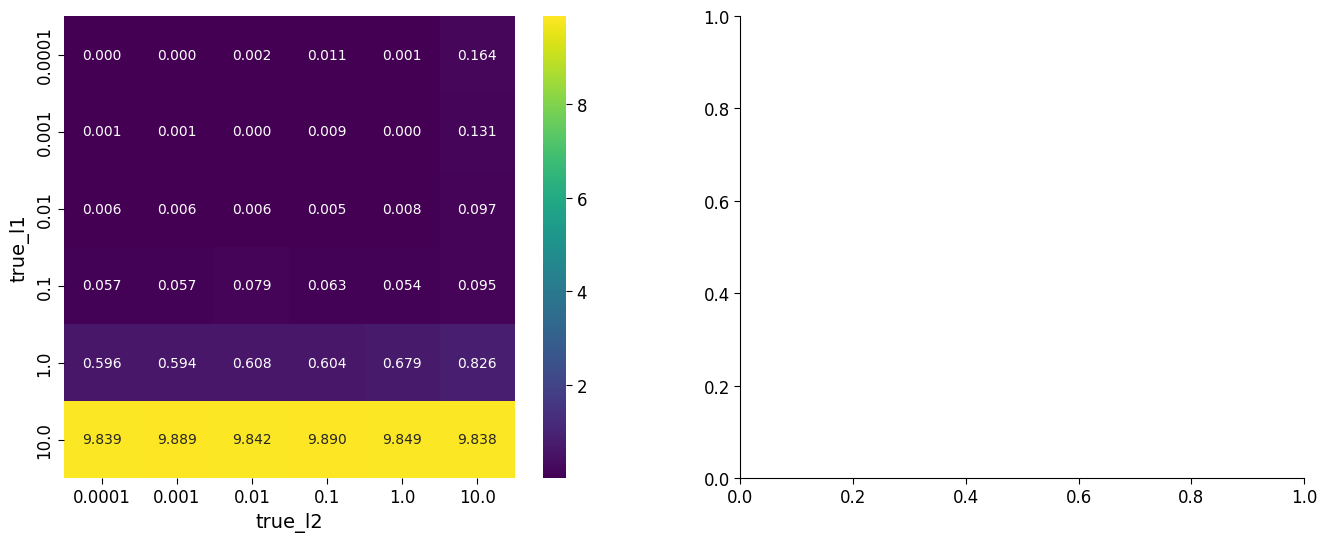

In [5]:
# Load your sweep results
df = pd.read_csv(f"sweep_{sweep.name}_results.csv")

# exponentiate the bias/theta_* terms so they are positive
df["bias/lambda_1"] = df["bias/theta_1"].apply(np.exp)
df["bias/lambda_2"] = df["bias/theta_2"].apply(np.exp)

# Rename for clarity
df = df.rename(columns={
    "l1": "true_l1",
    "l2": "true_l2",
    "bias/lambda_1": "estimated_l1",
    "bias/lambda_2": "estimated_l2"
})

# Compute errors
df["l1_error"] = (df["true_l1"] - df["estimated_l1"]).abs()
df["l2_error"] = (df["true_l2"] - df["estimated_l2"]).abs()
df["total_error"] = df["l1_error"] + df["l2_error"]


# ---- HEATMAPS: L1 and L2 Error ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# L1 Error Heatmap
heatmap_l1 = df.pivot_table(index="true_l1", columns="true_l2", values="l1_error")
sns.heatmap(heatmap_l1, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title(f"L1 Bias Recovery Error \n Smoothing: $\\beta = {sweep.config['parameters']['smooth']['value']}$")
axes[0].set_xlabel("True L2")
axes[0].set_ylabel("True L1")
axes[0].invert_yaxis()

# L2 Error Heatmap
heatmap_l2 = df.pivot_table(index="true_l1", columns="true_l2", values="l2_error")
sns.heatmap(heatmap_l2, annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
axes[1].set_title(f"L2 Bias Recovery Error \n Smoothing: $\\beta = {sweep.config['parameters']['smooth']['value']}$")
axes[1].set_xlabel("True L2")
axes[1].set_ylabel("True L1")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
fig.savefig(f"sweep_{sweep.name}_elasticnet_estimation_heatmap.pdf")

from matplotlib.colors import LogNorm

# ---- SCATTER: Estimated vs True L1 and L2 ----
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Scatter plot for L1
norm_l1 = LogNorm(
    vmin=df["true_l2"].min(),
    vmax=df["true_l2"].max()
)
sns.scatterplot(x="true_l1", y="estimated_l1", hue="true_l2", hue_norm=norm_l1, data=df, ax=axes[0])
axes[0].plot([df["true_l1"].min(), df["true_l1"].max()],
         [df["true_l1"].min(), df["true_l1"].max()], linestyle="--", color="gray")
axes[0].set_title(f"Estimated vs True L1 \n Smoothing: $\\beta = {sweep.config['parameters']['smooth']['value']}$", pad=20)
axes[0].set_xlabel("True L1")
axes[0].set_ylabel("Estimated L1")
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# # annotate the plots with the smoothing value beta
# axes[0].annotate(
#     f"L1 smoothing: $\\beta = {sweep.config["parameters"]["smooth"]["value"]}$",
#     xy=(0.5, 0.95), xycoords="axes fraction",
#     fontsize=12, ha="center"
# )

# Scatter plot for L2
norm_l2 = LogNorm(
    vmin=df["true_l1"].min(),
    vmax=df["true_l1"].max()
)
sns.scatterplot(x="true_l2", y="estimated_l2", hue="true_l1", hue_norm=norm_l2, data=df, ax=axes[1])
axes[1].plot([df["true_l2"].min(), df["true_l2"].max()],
         [df["true_l2"].min(), df["true_l2"].max()], linestyle="--", color="gray")
axes[1].set_title(f"Estimated vs True L2 \n Smoothing: $\\beta = {sweep.config['parameters']['smooth']['values']}$", pad=20)
axes[1].set_xlabel("True L2")
axes[1].set_ylabel("Estimated L2")
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()
# Save the figure
fig.savefig(f"sweep_{sweep.name}_elasticnet_estimation_scatter.pdf")


In [11]:
import torch
torch.allclose(torch.exp(torch.tensor(df["bias/theta_1"].values)), torch.tensor(np.exp(df["bias/theta_1"].values)))


True

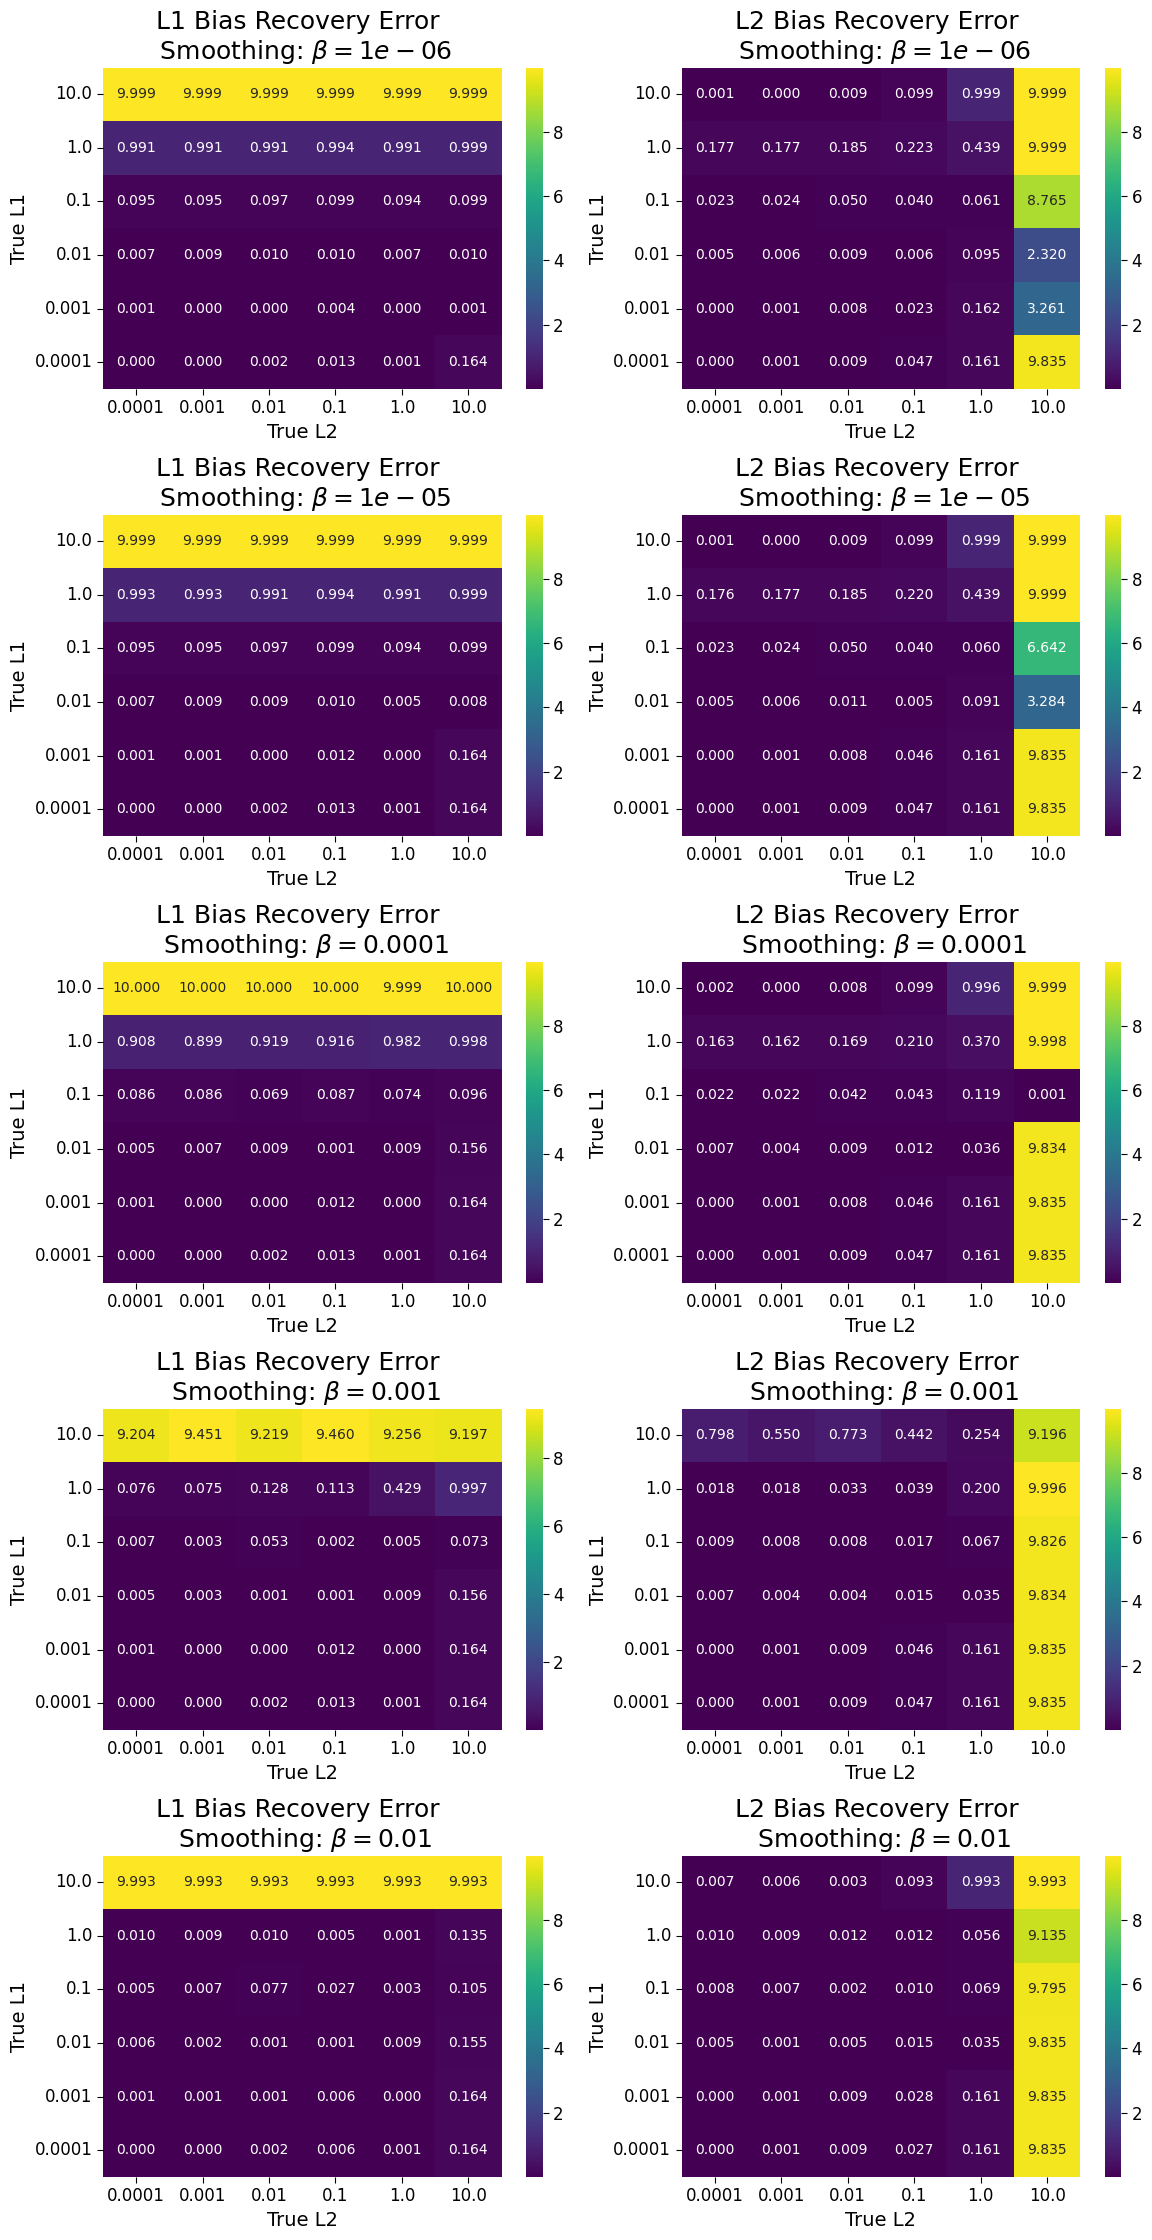

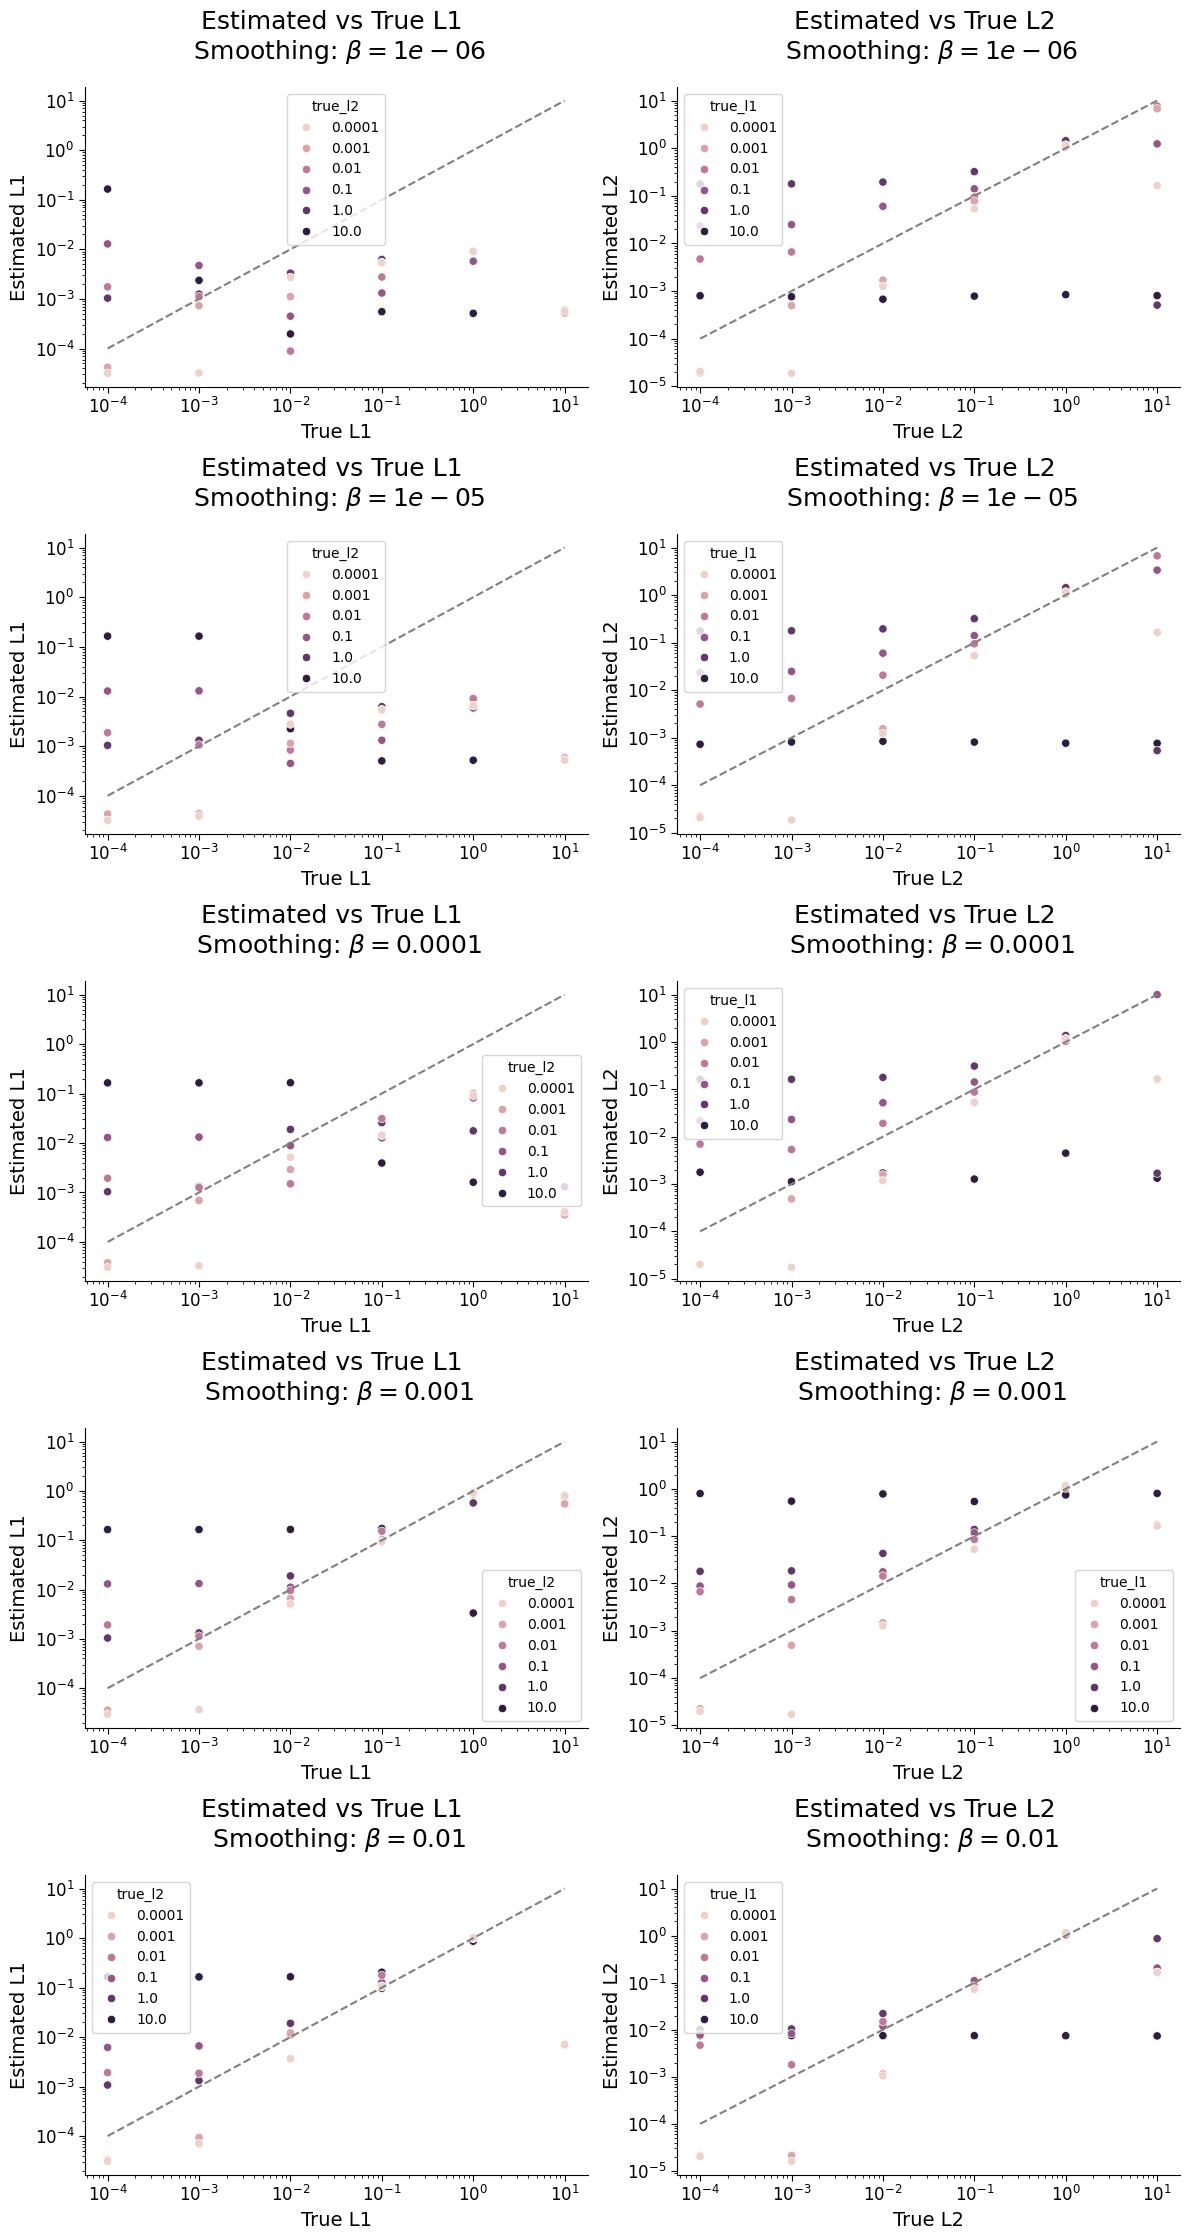

In [12]:
# Load your sweep results
df = pd.read_csv(f"sweep_{sweep.name}_results.csv")

# exponentiate the bias/theta_* terms so they are positive
df["bias/lambda_1"] = df["bias/theta_1"].apply(np.exp)
df["bias/lambda_2"] = df["bias/theta_2"].apply(np.exp)

# Rename for clarity
df = df.rename(columns={
    "l1": "true_l1",
    "l2": "true_l2",
    "bias/lambda_1": "estimated_l1",
    "bias/lambda_2": "estimated_l2"
})

# Compute errors
df["l1_error"] = (df["true_l1"] - df["estimated_l1"]).abs()
df["l2_error"] = (df["true_l2"] - df["estimated_l2"]).abs()
df["total_error"] = df["l1_error"] + df["l2_error"]

grouped_by_smooth = df.groupby("smooth")

# ---- HEATMAPS: L1 and L2 Error ----
n_rows = len(grouped_by_smooth)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4.5 * n_rows), squeeze=False)
for idx, (smooth_value, group_df) in enumerate(grouped_by_smooth):
    # L1 Error Heatmap
    heatmap_l1 = group_df.pivot_table(index="true_l1", columns="true_l2", values="l1_error")
    sns.heatmap(heatmap_l1, annot=True, fmt=".3f", cmap="viridis", ax=axes[idx, 0])
    axes[idx, 0].set_title(f"L1 Bias Recovery Error \n Smoothing: $\\beta = {smooth_value}$")
    axes[idx, 0].set_xlabel("True L2")
    axes[idx, 0].set_ylabel("True L1")
    axes[idx, 0].invert_yaxis()

    # L2 Error Heatmap
    heatmap_l2 = group_df.pivot_table(index="true_l1", columns="true_l2", values="l2_error")
    sns.heatmap(heatmap_l2, annot=True, fmt=".3f", cmap="viridis", ax=axes[idx, 1])
    axes[idx, 1].set_title(f"L2 Bias Recovery Error \n Smoothing: $\\beta = {smooth_value}$")
    axes[idx, 1].set_xlabel("True L2")
    axes[idx, 1].set_ylabel("True L1")
    axes[idx, 1].invert_yaxis()

plt.tight_layout()
plt.show()
fig.savefig(f"sweep_{sweep.name}_elasticnet_estimation_heatmap.pdf")

from matplotlib.colors import LogNorm

# ---- SCATTER: Estimated vs True L1 and L2 ----
n_rows = len(grouped_by_smooth)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4.5 * n_rows), squeeze=False)
for idx, (smooth_value, group_df) in enumerate(grouped_by_smooth):
    norm_l1 = LogNorm(
        vmin=group_df["true_l2"].min(),
        vmax=group_df["true_l2"].max()
    )
    norm_l2 = LogNorm(
        vmin=group_df["true_l1"].min(),
        vmax=group_df["true_l1"].max()
    )
    sns.scatterplot(x="true_l1", y="estimated_l1", hue="true_l2", hue_norm=norm_l1, data=group_df, ax=axes[idx, 0])
    axes[idx, 0].plot([group_df["true_l1"].min(), group_df["true_l1"].max()],
            [group_df["true_l1"].min(), group_df["true_l1"].max()], linestyle="--", color="gray")
    axes[idx, 0].set_title(f"Estimated vs True L1 \n Smoothing: $\\beta = {smooth_value}$", pad=20)
    axes[idx, 0].set_xlabel("True L1")
    axes[idx, 0].set_ylabel("Estimated L1")
    axes[idx, 0].set_xscale('log')
    axes[idx, 0].set_yscale('log')
    sns.scatterplot(x="true_l2", y="estimated_l2", hue="true_l1", hue_norm=norm_l2, data=group_df, ax=axes[idx, 1])
    axes[idx, 1].plot([group_df["true_l2"].min(), group_df["true_l2"].max()],
            [group_df["true_l2"].min(), group_df["true_l2"].max()], linestyle="--", color="gray")
    axes[idx, 1].set_title(f"Estimated vs True L2 \n Smoothing: $\\beta = {smooth_value}$", pad=20)
    axes[idx, 1].set_xlabel("True L2")
    axes[idx, 1].set_ylabel("Estimated L2")
    axes[idx, 1].set_xscale('log')
    axes[idx, 1].set_yscale('log')

plt.tight_layout()
plt.show()
# Save the figure
fig.savefig(f"sweep_{sweep.name}_elasticnet_estimation_scatter.pdf")

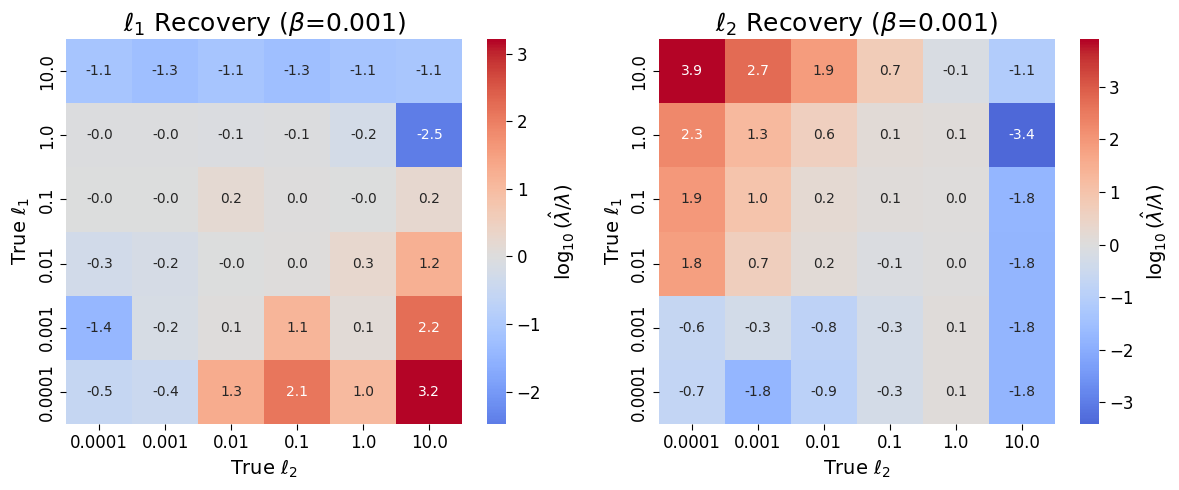

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to a single smoothing value
df_beta = df.query("smooth == 0.001").copy()

# Ensure positivity
df_beta = df_beta[(df_beta["true_l1"] > 0) & (df_beta["true_l2"] > 0) &
                  (df_beta["estimated_l1"] > 0) & (df_beta["estimated_l2"] > 0)]

# Pivot: estimated and true values
est_l1 = df_beta.pivot(index="true_l1", columns="true_l2", values="estimated_l1")
est_l2 = df_beta.pivot(index="true_l1", columns="true_l2", values="estimated_l2")
true_l1 = df_beta.pivot(index="true_l1", columns="true_l2", values="true_l1")
true_l2 = df_beta.pivot(index="true_l1", columns="true_l2", values="true_l2")

# Compute signed log10 error
logerr_l1 = np.log10(est_l1 / true_l1)
logerr_l2 = np.log10(est_l2 / true_l2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    logerr_l1, annot=True, fmt=".1f", cmap="coolwarm", center=0,
    cbar_kws={"label": r"$\log_{10}(\hat{\lambda}/\lambda)$"}, ax=axes[0]
)
axes[0].set_title(r"$\ell_1$ Recovery ($\beta$=0.001)")
axes[0].set_xlabel(r"True $\ell_2$"); axes[0].set_ylabel(r"True $\ell_1$")
axes[0].invert_yaxis()

sns.heatmap(
    logerr_l2, annot=True, fmt=".1f", cmap="coolwarm", center=0,
    cbar_kws={"label": r"$\log_{10}(\hat{\lambda}/\lambda)$"}, ax=axes[1]
)
axes[1].set_title(r"$\ell_2$ Recovery ($\beta$=0.001)")
axes[1].set_xlabel(r"True $\ell_2$"); axes[1].set_ylabel(r"True $\ell_1$")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

/tmp/ipykernel_129385/3972159207.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave room for shared cbar


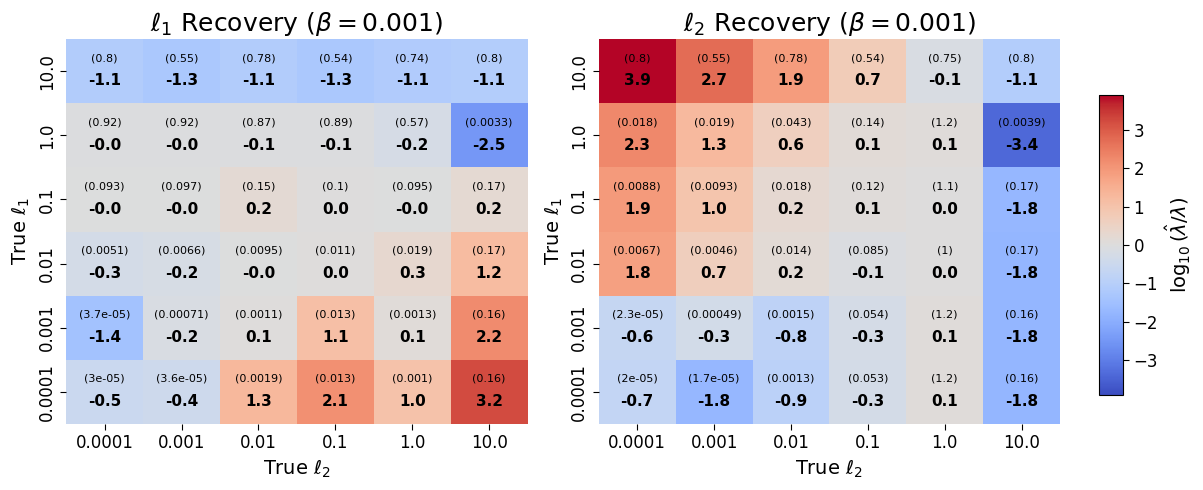

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ... same setup code as you already have ...

# Compute signed log10 error
logerr_l1 = np.log10(est_l1 / true_l1)
logerr_l2 = np.log10(est_l2 / true_l2)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# assume you already have est_l1, est_l2, true_l1, true_l2, logerr_l1, logerr_l2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# global normalization
all_vals = np.concatenate([logerr_l1.values.ravel(), logerr_l2.values.ravel()])
vmax = np.nanmax(np.abs(all_vals))
norm_kwargs = dict(vmin=-vmax, vmax=vmax, center=0, cmap="coolwarm")

# plot both heatmaps with the same normalization, but suppress their individual cbar
sns.heatmap(logerr_l1, annot=False, cbar=False, ax=axes[0], **norm_kwargs)
sns.heatmap(logerr_l2, annot=False, cbar=False, ax=axes[1], **norm_kwargs)

# titles/labels
axes[0].set_title(r"$\ell_1$ Recovery ($\beta=0.001$)")
axes[0].set_xlabel(r"True $\ell_2$"); axes[0].set_ylabel(r"True $\ell_1$")
axes[0].invert_yaxis()

axes[1].set_title(r"$\ell_2$ Recovery ($\beta=0.001$)")
axes[1].set_xlabel(r"True $\ell_2$"); axes[1].set_ylabel(r"True $\ell_1$")
axes[1].invert_yaxis()

# annotate both: logerr (big bold) + estimate (small)
for mat, est, ax in [(logerr_l1, est_l1, axes[0]), (logerr_l2, est_l2, axes[1])]:
    for i, y in enumerate(mat.index):
        for j, x in enumerate(mat.columns):
            val = mat.loc[y, x]
            est_val = est.loc[y, x]
            if np.isfinite(val) and np.isfinite(est_val):
                ax.text(j+0.5, i+0.35, f"{val:.1f}",
                        ha="center", va="center", fontsize=11, fontweight="bold")
                ax.text(j+0.5, i+0.70, f"({est_val:.2g})",
                        ha="center", va="center", fontsize=8)

# add one shared colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=-vmax, vmax=vmax))
fig.colorbar(sm, cax=cbar_ax, label=r"$\log_{10}(\hat{\lambda}/\lambda)$")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave room for shared cbar

plt.savefig(f"sweep_{sweep.name}_elasticnet_estimation_heatmap_detailed.pdf")

plt.show()

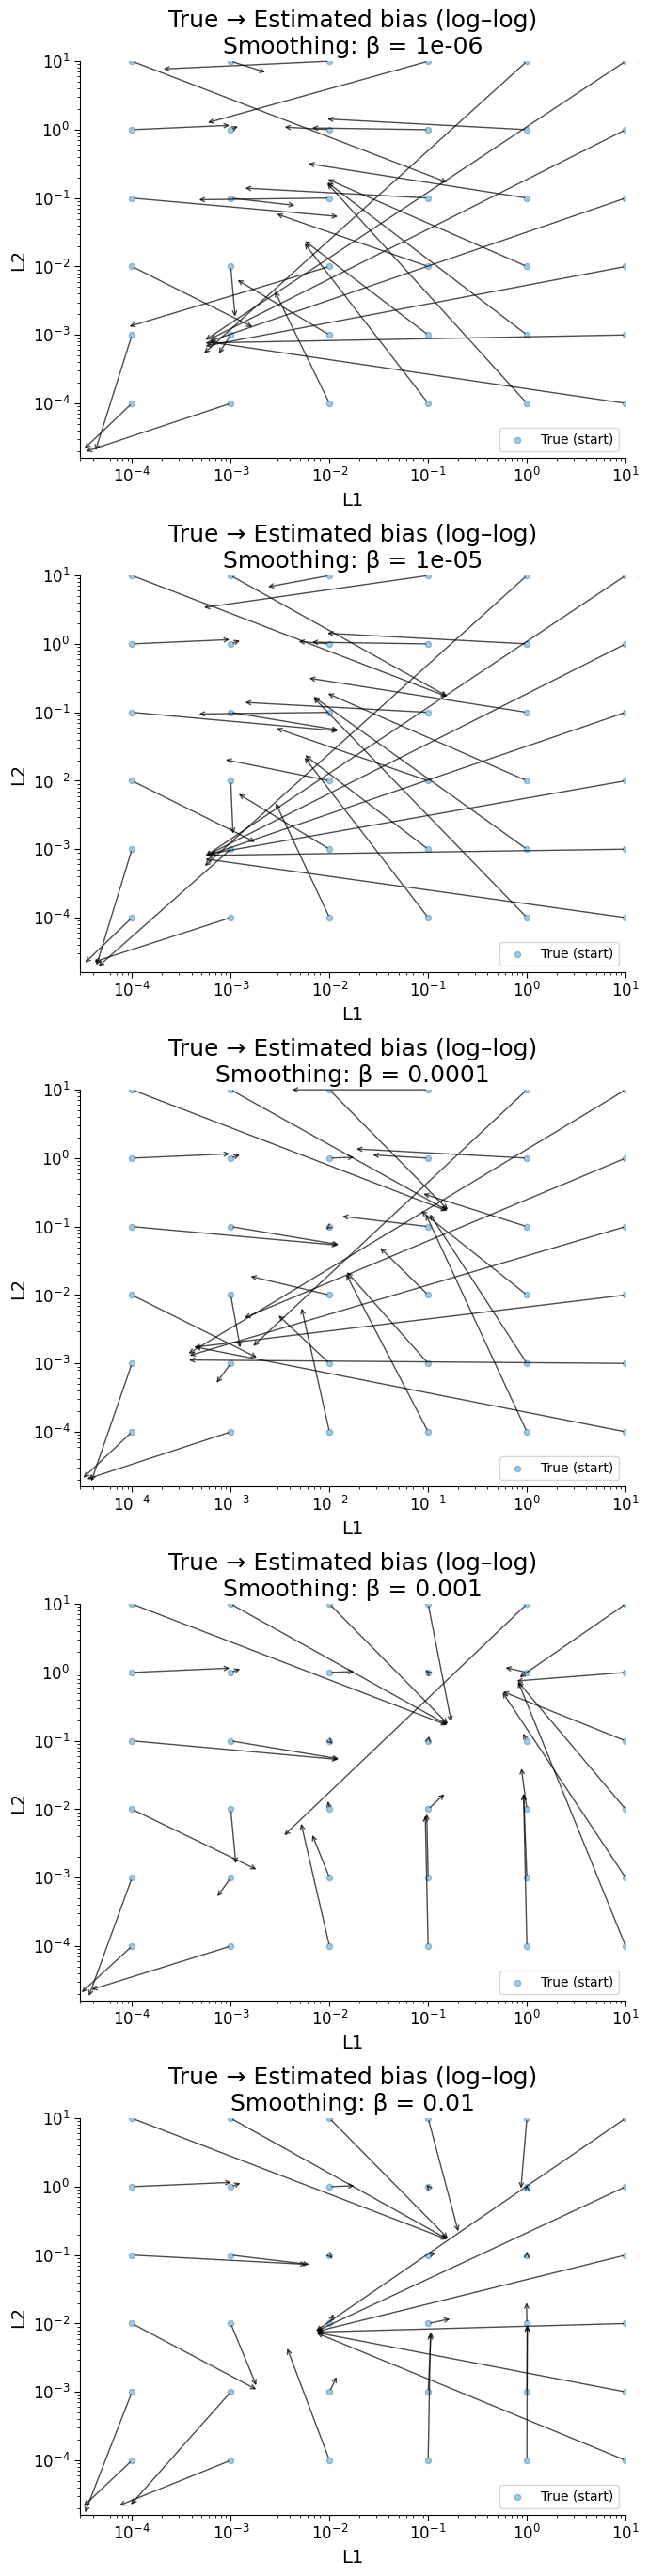

In [13]:
from typing import Optional, Iterable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_arrow_facets_by_smooth(
    df: pd.DataFrame,
    savepath: Optional[str] = None,
    max_arrows_per_panel: Optional[int] = None,
    jitter: float = 0.0,
) -> plt.Figure:
    """
    Faceted arrow plots (True -> Estimated) for each `smooth` value.

    Expects columns:
      - 'true_l1', 'true_l2'             (positive)
      - 'estimated_l1', 'estimated_l2'   (should be positive after your exp)
      - 'smooth'

    Args:
        df: DataFrame as above.
        savepath: Optional path to save a PDF/PNG (inferred by extension).
        max_arrows_per_panel: If set, subsample per panel to limit clutter.
        jitter: multiplicative log-jitter applied to TRUE points (e.g., 0.02 = ±2%).
    """
    # Keep only rows we can show on log axes
    dfo = df.copy()
    dfo = dfo[
        (dfo["true_l1"] > 0) & (dfo["true_l2"] > 0)
        & (dfo["estimated_l1"] > 0) & (dfo["estimated_l2"] > 0)
    ].reset_index(drop=True)

    grouped = dfo.groupby("smooth", sort=True)
    n = len(grouped)
    if n == 0:
        raise ValueError("No valid (positive) rows to plot on log–log axes.")

    fig, axes = plt.subplots(n, 1, figsize=(7, 5.5 * n), squeeze=False)
    axes = axes.ravel()

    # global axis limits across panels for visual comparability
    all_true_l1 = dfo["true_l1"].values
    all_true_l2 = dfo["true_l2"].values
    all_est_l1  = dfo["estimated_l1"].values
    all_est_l2  = dfo["estimated_l2"].values
    x_min = float(np.min([all_true_l1.min(), all_est_l1.min()]))
    x_max = float(np.max([all_true_l1.max(), all_est_l1.max()]))
    y_min = float(np.min([all_true_l2.min(), all_est_l2.min()]))
    y_max = float(np.max([all_true_l2.max(), all_est_l2.max()]))

    for ax, (smooth_value, g) in zip(axes, grouped):
        g = g.copy()
        if max_arrows_per_panel is not None and len(g) > max_arrows_per_panel:
            g = g.sample(n=max_arrows_per_panel, random_state=0)

        # optional tiny multiplicative jitter (helps reveal overplotting on grid points)
        if jitter > 0.0:
            r1 = np.exp(np.random.uniform(-jitter, jitter, size=len(g)))
            r2 = np.exp(np.random.uniform(-jitter, jitter, size=len(g)))
            g.loc[:, "true_l1_j"] = g["true_l1"].to_numpy() * r1
            g.loc[:, "true_l2_j"] = g["true_l2"].to_numpy() * r2
        else:
            g.loc[:, "true_l1_j"] = g["true_l1"]
            g.loc[:, "true_l2_j"] = g["true_l2"]

        # draw faint start points (true) and arrows to estimates
        ax.scatter(g["true_l1_j"], g["true_l2_j"], s=20, alpha=0.4, label="True (start)")

        # arrows
        for t1, t2, e1, e2 in zip(g["true_l1_j"], g["true_l2_j"], g["estimated_l1"], g["estimated_l2"]):
            # Use annotate (more stable on log axes than plt.arrow)
            ax.annotate(
                "", xy=(e1, e2), xytext=(t1, t2),
                arrowprops=dict(arrowstyle="->", lw=1.0, alpha=0.7, mutation_scale=8),
            )

        # diagonal reference in each panel is not meaningful (different axes), so omit
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
        ax.set_xlabel("L1"); ax.set_ylabel("L2")
        ax.set_title(f"True → Estimated bias (log–log)\nSmoothing: β = {smooth_value}")
        ax.legend(loc="lower right")

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches="tight")
    return fig

# Call after preparing df exactly as in your snippet
fig = plot_arrow_facets_by_smooth(
    df,
    savepath=f"sweep_{sweep.name}_elasticnet_arrow_facets.pdf",
    max_arrows_per_panel=None,   # or an int like 150 to declutter
    jitter=0.0                   # e.g., 0.02 for ±2% multiplicative jitter
)
plt.show()

## config stuff

In [ ]:
import yaml


def read_config(path: str):
    """read yaml file"""
    with open(path, 'r') as f:
        data = yaml.safe_load(f)
    return data

In [ ]:
config = read_config("elasticnet_sweep_config.yaml")

In [ ]:
config["parameters"]["smooth"]["values"]

[0.01, 0.001, 0.0001, 1e-05, 1e-06]